In [37]:
import numpy as np
import pandas as pd

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [39]:
data=pd.read_csv(r"/content/Wine_Quality (1).csv")

In [40]:
data.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [41]:
data.isnull().sum()

,0
type,0
fixed acidity,10
volatile acidity,8
citric acid,3
residual sugar,2
chlorides,2
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,9


In [42]:
data.interpolate(method='linear',inplace=True)

<ipython-input-42-8558fe75f3f9>:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  data.interpolate(method='linear',inplace=True)


In [43]:
x=data[["fixed acidity","volatile acidity","citric acid","residual sugar","chlorides","free sulfur dioxide","total sulfur dioxide","density","pH","sulphates","alcohol"]]

In [44]:
data.isnull().sum()

,0
type,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0


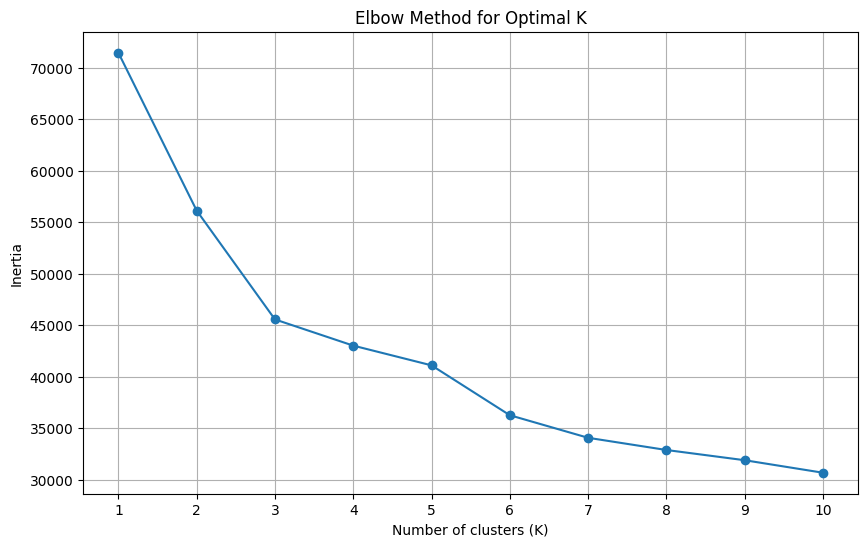

In [34]:
from matplotlib import pyplot as plt
# Scale the data
scaler = StandardScaler()
x_scale= scaler.fit_transform(x)

# Determine optimal K using elbow method
K_range = range(1, 11)
inertia = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x_scale)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.grid()
plt.show()


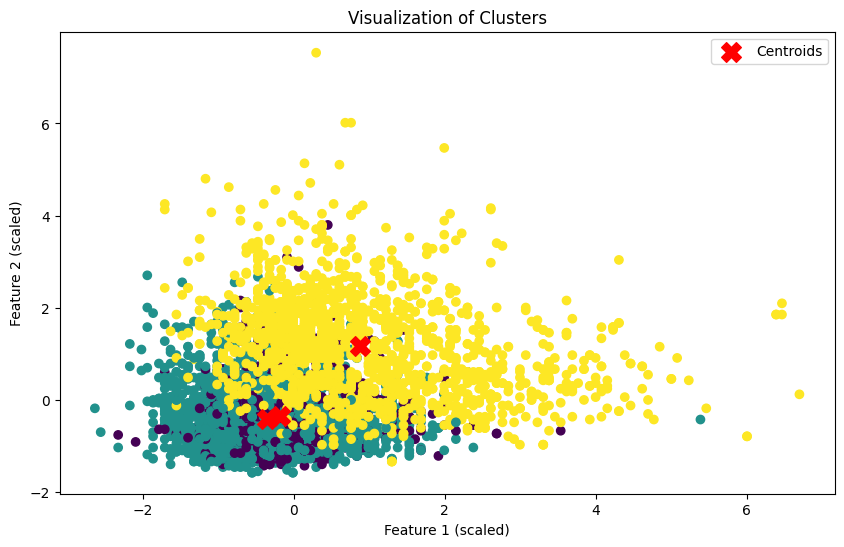

In [51]:
# prompt: give me the code for visualize clusers and mark the centroid

kmeans = KMeans(n_clusters=3, random_state=42)  # Replace 3 with your chosen K
kmeans.fit(x_scale)

# Get cluster labels and centroids
labels = kmeans.labels_
centroids = kmeans.cluster_centers_

# Visualize the clusters (using only the first two features for plotting)
plt.figure(figsize=(10, 6))
plt.scatter(x_scale[:, 0], x_scale[:, 1], c=labels, cmap='viridis')
plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200, c='red', label='Centroids')
plt.xlabel('Feature 1 (scaled)')
plt.ylabel('Feature 2 (scaled)')
plt.title('Visualization of Clusters')
plt.legend()
plt.show()

In [50]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

# Split the data
x_train, x_test, y_train, y_test = train_test_split(x_scaled, data['quality'], test_size=0.2, random_state=42)

# Create and fit the KMeans model
model = KMeans(n_clusters=3, random_state=42)
model.fit(x_train)



KMeans(n_clusters=3, random_state=42)

In [48]:
# prompt: what is the other cluster make a fuction with prompt to accept user input

def predict_cluster_with_input():
  """Predicts the cluster for user input."""

  fixed_acidity = float(input("Enter fixed acidity: "))
  volatile_acidity = float(input("Enter volatile acidity: "))
  citric_acid = float(input("Enter citric acid: "))
  residual_sugar = float(input("Enter residual sugar: "))
  chlorides = float(input("Enter chlorides: "))
  free_sulfur_dioxide = float(input("Enter free sulfur dioxide: "))
  total_sulfur_dioxide = float(input("Enter total sulfur dioxide: "))
  density = float(input("Enter density: "))
  pH = float(input("Enter pH: "))
  sulphates = float(input("Enter sulphates: "))
  alcohol = float(input("Enter alcohol: "))


  user_input = [fixed_acidity, volatile_acidity, citric_acid, residual_sugar,
                chlorides, free_sulfur_dioxide, total_sulfur_dioxide, density,
                pH, sulphates, alcohol]

  user_input_scaled = scaler.transform([user_input])
  cluster = model.predict(user_input_scaled)
  return cluster[0]

# Get the predicted cluster based on user input
predicted_cluster = predict_cluster_with_input()
print(f'The predicted cluster for the user input is: {predicted_cluster}')

Enter fixed acidity: 3
Enter volatile acidity: 4
Enter citric acid: 5
Enter residual sugar: 6
Enter chlorides: 7
Enter free sulfur dioxide: 2
Enter total sulfur dioxide: 5
Enter density: 8
Enter pH: 9
Enter sulphates: 9
Enter alcohol: 4
The predicted cluster for the user input is: 0


/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
